# Geo-FNO No-IPHI (Clean)

This notebook trains and evaluates Geo-FNO with `IPHI` fully removed.

In [10]:
import os
import json
import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as tri
from typing import Tuple

import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader, Subset

import importlib
import geo_FNO_def
importlib.reload(geo_FNO_def)
FNO2d = geo_FNO_def.FNO2d
get_global_L_from_h5 = geo_FNO_def.get_global_L_from_h5


In [11]:
# ----------------------------
# Config
# ----------------------------
TRAIN_H5 = '/scratch/mnhagen/datasets/incompressible_euler/train.h5'
TEST_H5  = '/scratch/mnhagen/datasets/incompressible_euler/test.h5'
SAVE_DIR = '/scratch/mnhagen/models/geofno'
RUN_NAME = 'cylinder_vel_t0_t-1_1sample_noiphi'

DEVICE = 'cuda:0' if torch.cuda.is_available() else 'cpu'
print('Using device:', DEVICE)

# Data/time setup
NTRAIN = 1
NTEST = 1
T_IN = 0
T_OUT = -1
BATCH_SIZE = 1

# Model/training setup
MODES = 12
WIDTH = 32
S1 = 100
S2 = 25
EPOCHS = 100
LR_FNO = 1e-3
WEIGHT_DECAY = 1e-4
VAL_PATIENCE = 1000
IMPROVE_THRESH = 1e-3

# Spectral ablation/regularization toggles
SPECTRAL_ENFORCE_REAL = True
SPECTRAL_TIE_WEIGHTS = True
LAMBDA_IMAG = 1e-4


Using device: cuda:0


In [12]:
# ----------------------------
# Dataset (no geometry code needed)
# ----------------------------
def compute_node_quadrature_weights(pos: np.ndarray, cells: np.ndarray) -> np.ndarray:
    """Mass-lumped node quadrature: 1/3 triangle area to each incident node."""
    w = np.zeros((pos.shape[0],), dtype=np.float64)
    for tri_idx in cells:
        p0, p1, p2 = pos[tri_idx[0]], pos[tri_idx[1]], pos[tri_idx[2]]
        area = 0.5 * abs(np.cross(p1 - p0, p2 - p0))
        share = area / 3.0
        w[tri_idx[0]] += share
        w[tri_idx[1]] += share
        w[tri_idx[2]] += share

    # Keep average weight near 1 for stable optimization scale.
    w = w / (w.mean() + 1e-12)
    return w.astype(np.float32)


class CylinderFlowNoIPhiDataset(Dataset):
    def __init__(self, h5_path: str, t_in: int = 0, t_out: int = -1):
        super().__init__()
        self.f = h5py.File(h5_path, 'r')
        self.keys = sorted([k for k in self.f.keys() if k.startswith('sample_')])
        self.t_in = t_in
        self.t_out = t_out

    def __len__(self):
        return len(self.keys)

    def __getitem__(self, idx: int):
        key = self.keys[idx]
        g = self.f[key]
        pos = g['pos'][:].astype(np.float32)      # (N,2)
        cells = g['cells'][:]
        vel = g['vel'][:].astype(np.float32)      # (T,N,2)
        u_in = vel[self.t_in]                     # (N,2)
        u_out = vel[self.t_out]                   # (N,2)
        w = compute_node_quadrature_weights(pos, cells)  # (N,)
        return (
            torch.from_numpy(pos),
            torch.from_numpy(u_in),
            torch.from_numpy(u_out),
            torch.from_numpy(w),
        )


def collate_bs1(batch):
    return batch[0]


In [13]:
# ----------------------------
# Train (IPHI removed)
# ----------------------------
def train_geofno_no_iphi(
    train_h5: str,
    test_h5: str,
    ntrain: int,
    ntest: int,
    t_in: int,
    t_out: int,
    batch_size: int,
    epochs: int,
    learning_rate_fno: float,
    modes: int,
    width: int,
    s1: int,
    s2: int,
    device: str,
    val_patience: int,
    improve_thresh: float,
    spectral_enforce_real: bool,
    spectral_tie_weights: bool,
    lambda_imag: float,
):
    train_ds = CylinderFlowNoIPhiDataset(train_h5, t_in=t_in, t_out=t_out)
    test_ds  = CylinderFlowNoIPhiDataset(test_h5,  t_in=t_in, t_out=t_out)

    train_loader = DataLoader(
        Subset(train_ds, range(min(ntrain, len(train_ds)))),
        batch_size=batch_size,
        shuffle=False,
        collate_fn=collate_bs1,
    )
    test_loader = DataLoader(
        Subset(test_ds, range(min(ntest, len(test_ds)))),
        batch_size=batch_size,
        shuffle=False,
        collate_fn=collate_bs1,
    )

    subset_indices = train_loader.dataset.indices
    print('Training subset indices:', subset_indices)
    print('Training sample keys:', [train_ds.keys[i] for i in subset_indices])

    L_global, key_used = get_global_L_from_h5(train_h5)
    print('Using global L from', key_used, ':', L_global)

    model = FNO2d(
        modes, modes, width,
        in_channels=2, out_channels=2,
        is_mesh=False, s1=s1, s2=s2,
        L=L_global,
        spectral_enforce_real=spectral_enforce_real,
        spectral_tie_weights=spectral_tie_weights,
    ).to(device)

    # Track imaginary leakage from inverse spectral reconstruction in conv4.
    model.conv4.track_imag_energy = (lambda_imag > 0.0)

    opt_fno = Adam(model.parameters(), lr=learning_rate_fno, weight_decay=WEIGHT_DECAY)
    loss_fn = nn.MSELoss()

    best_val_loss = 1e12
    epochs_no_improve = 0

    for ep in range(epochs):
        model.train()
        train_loss = 0.0

        for pos, u_in, u_out, w in train_loader:
            pos = pos.unsqueeze(0).to(device)
            u_in = u_in.unsqueeze(0).to(device)
            u_out = u_out.unsqueeze(0).to(device)
            w = w.unsqueeze(0).to(device)

            opt_fno.zero_grad()
            pred = model(u_in, x_in=pos, x_out=pos, iphi=None, x_in_w=w, x_out_w=w)
            data_loss = loss_fn(pred, u_out)
            imag_pen = model.conv4.last_imag_energy if (lambda_imag > 0.0 and model.conv4.last_imag_energy is not None) else 0.0
            loss = data_loss + lambda_imag * imag_pen
            loss.backward()
            opt_fno.step()

            train_loss += float(loss.item())

        train_loss /= max(1, len(train_loader))

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for pos, u_in, u_out, w in test_loader:
                pos = pos.unsqueeze(0).to(device)
                u_in = u_in.unsqueeze(0).to(device)
                u_out = u_out.unsqueeze(0).to(device)
                w = w.unsqueeze(0).to(device)
                pred = model(u_in, x_in=pos, x_out=pos, iphi=None, x_in_w=w, x_out_w=w)
                val_loss += float(loss_fn(pred, u_out).item())

        val_loss /= max(1, len(test_loader))
        print(f'ep={ep:04d} train={train_loss:.6e} val={val_loss:.6e}')

        if val_loss < best_val_loss * (1 - improve_thresh):
            best_val_loss = val_loss
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= val_patience:
                print('Early stop triggered.')
                break

        if ep % 100 == 0:
            os.makedirs('./checkpoints', exist_ok=True)
            torch.save(model.state_dict(), f'./checkpoints/geofno_noiphi_ep{ep}.pt')

    print('Best val loss tracked:', best_val_loss)
    print('Returning last-epoch weights.')
    print('spectral_enforce_real=', spectral_enforce_real,
          'spectral_tie_weights=', spectral_tie_weights,
          'lambda_imag=', lambda_imag)
    return model, train_ds


In [14]:
model, train_ds = train_geofno_no_iphi(
    train_h5=TRAIN_H5,
    test_h5=TEST_H5,
    ntrain=NTRAIN,
    ntest=NTEST,
    t_in=T_IN,
    t_out=T_OUT,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    learning_rate_fno=LR_FNO,
    modes=MODES,
    width=WIDTH,
    s1=S1,
    s2=S2,
    device=DEVICE,
    val_patience=VAL_PATIENCE,
    improve_thresh=IMPROVE_THRESH,
    spectral_enforce_real=SPECTRAL_ENFORCE_REAL,
    spectral_tie_weights=SPECTRAL_TIE_WEIGHTS,
    lambda_imag=LAMBDA_IMAG,
)


Training subset indices: range(0, 1)
Training sample keys: ['sample_000000']
Using global L from sample_000000 : [1.600000023841858, 0.4099999964237213]


/tmp/ipykernel_651971/1809071456.py:9: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  area = 0.5 * abs(np.cross(p1 - p0, p2 - p0))


ep=0000 train=6.537173e-02 val=8.506421e-01
ep=0001 train=4.318990e-02 val=7.701552e-01
ep=0002 train=2.867412e-02 val=6.979648e-01
ep=0003 train=2.135453e-02 val=6.365012e-01
ep=0004 train=2.059523e-02 val=5.931604e-01
ep=0005 train=2.387344e-02 val=5.731438e-01
ep=0006 train=2.648414e-02 val=5.707285e-01
ep=0007 train=2.639935e-02 val=5.793958e-01
ep=0008 train=2.440233e-02 val=5.944554e-01
ep=0009 train=2.185369e-02 val=6.125726e-01
ep=0010 train=1.968656e-02 val=6.313293e-01
ep=0011 train=1.827870e-02 val=6.489924e-01
ep=0012 train=1.762003e-02 val=6.643577e-01
ep=0013 train=1.750649e-02 val=6.766360e-01
ep=0014 train=1.767853e-02 val=6.853791e-01
ep=0015 train=1.790190e-02 val=6.904355e-01
ep=0016 train=1.800734e-02 val=6.919070e-01
ep=0017 train=1.790269e-02 val=6.900974e-01
ep=0018 train=1.756650e-02 val=6.854543e-01
ep=0019 train=1.703105e-02 val=6.785186e-01
ep=0020 train=1.636145e-02 val=6.698818e-01
ep=0021 train=1.563495e-02 val=6.601527e-01
ep=0022 train=1.492290e-02 val=6

In [15]:
# ----------------------------
# Save (FNO only)
# ----------------------------
def save_no_iphi_checkpoint(model, folder: str, name: str, extra_meta: dict | None = None):
    os.makedirs(folder, exist_ok=True)
    model_path = os.path.join(folder, f'{name}_fno.pt')
    meta_path = os.path.join(folder, f'{name}_meta.json')

    torch.save(model.state_dict(), model_path)

    meta = {} if extra_meta is None else dict(extra_meta)
    meta['model_path'] = model_path
    with open(meta_path, 'w') as f:
        json.dump(meta, f, indent=2)

    print('Saved:', model_path)
    print('Saved:', meta_path)


save_no_iphi_checkpoint(
    model,
    folder=SAVE_DIR,
    name=RUN_NAME,
    extra_meta={
        't_in': T_IN,
        't_out': T_OUT,
        'ntrain': NTRAIN,
        'ntest': NTEST,
        'modes': MODES,
        'width': WIDTH,
        's1': S1,
        's2': S2,
        'iphi': None,
    },
)


Saved: /scratch/mnhagen/models/geofno/cylinder_vel_t0_t-1_1sample_noiphi_fno.pt
Saved: /scratch/mnhagen/models/geofno/cylinder_vel_t0_t-1_1sample_noiphi_meta.json


/tmp/ipykernel_651971/1809071456.py:9: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  area = 0.5 * abs(np.cross(p1 - p0, p2 - p0))


Sample: sample_000000 MSE: 0.001958241919055581


/tmp/ipykernel_651971/645436873.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


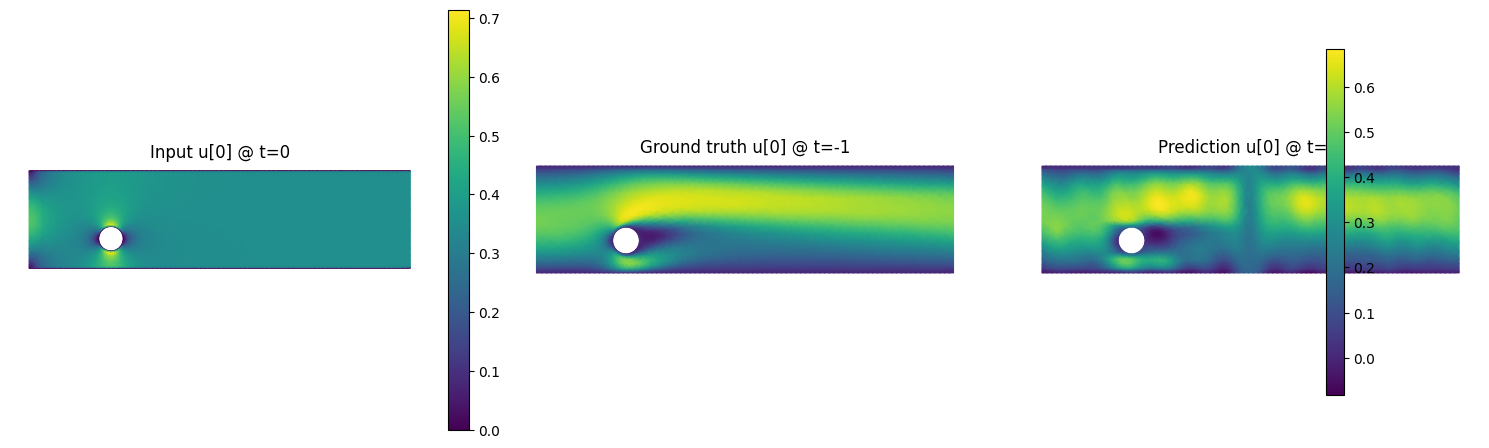

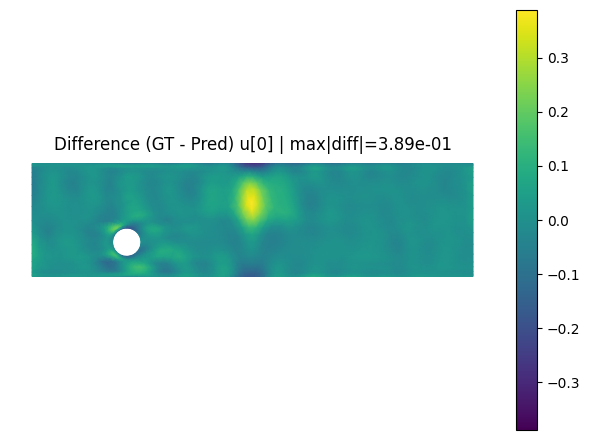

In [16]:
# ----------------------------
# Single-sample visualize (same trained sample by default)
# ----------------------------
H5_PATH = TRAIN_H5
sample_id = train_ds.keys[0]  # trained sample when NTRAIN=1 and sorted order
component = 0

FNO_CKPT = f'{SAVE_DIR}/{RUN_NAME}_fno.pt'

with h5py.File(H5_PATH, 'r') as f:
    g = f[sample_id]
    pos = g['pos'][:]
    cells = g['cells'][:]
    vel = g['vel'][:]

u_in_np = vel[T_IN].astype(np.float32)
u_out_np = vel[T_OUT].astype(np.float32)
w_np = compute_node_quadrature_weights(pos.astype(np.float32), cells)

L_global, _ = get_global_L_from_h5(H5_PATH)
device = torch.device(DEVICE)
model_eval = FNO2d(
    MODES, MODES, WIDTH,
    in_channels=2, out_channels=2,
    is_mesh=False, s1=S1, s2=S2,
    L=L_global,
    spectral_enforce_real=SPECTRAL_ENFORCE_REAL,
    spectral_tie_weights=SPECTRAL_TIE_WEIGHTS,
).to(device)
model_eval.load_state_dict(torch.load(FNO_CKPT, map_location=device))
model_eval.eval()

pos_t = torch.from_numpy(pos.astype(np.float32)).unsqueeze(0).to(device)
u_in_t = torch.from_numpy(u_in_np).unsqueeze(0).to(device)
w_t = torch.from_numpy(w_np).unsqueeze(0).to(device)

with torch.no_grad():
    pred_t = model_eval(u_in_t, x_in=pos_t, x_out=pos_t, iphi=None, x_in_w=w_t, x_out_w=w_t)

pred_np = pred_t[0].cpu().numpy().astype(np.float32)
mse = float(np.mean((pred_np - u_out_np) ** 2))
print('Sample:', sample_id, 'MSE:', mse)

triang = tri.Triangulation(pos[:, 0], pos[:, 1], cells)
inp_field = u_in_np[:, component]
gt_field = u_out_np[:, component]
pred_field = pred_np[:, component]
diff_field = gt_field - pred_field

common_min = float(min(gt_field.min(), pred_field.min()))
common_max = float(max(gt_field.max(), pred_field.max()))
diff_abs = float(np.max(np.abs(diff_field)))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
im0 = axes[0].tripcolor(triang, inp_field, shading='gouraud')
axes[0].set_title(f'Input u[{component}] @ t={T_IN}')
axes[0].set_aspect('equal'); axes[0].axis('off')
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].tripcolor(triang, gt_field, shading='gouraud', vmin=common_min, vmax=common_max)
axes[1].set_title(f'Ground truth u[{component}] @ t={T_OUT}')
axes[1].set_aspect('equal'); axes[1].axis('off')

im2 = axes[2].tripcolor(triang, pred_field, shading='gouraud', vmin=common_min, vmax=common_max)
axes[2].set_title(f'Prediction u[{component}] @ t={T_OUT}')
axes[2].set_aspect('equal'); axes[2].axis('off')

fig.colorbar(im1, ax=axes[1:], fraction=0.025, pad=0.04)
plt.tight_layout(); plt.show()

plt.figure(figsize=(6, 4.5))
imd = plt.tripcolor(triang, diff_field, shading='gouraud', vmin=-diff_abs, vmax=diff_abs)
plt.gca().set_aspect('equal')
plt.title(f'Difference (GT - Pred) u[{component}] | max|diff|={diff_abs:.2e}')
plt.axis('off')
plt.colorbar(imd, fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()


/tmp/ipykernel_651971/1809071456.py:9: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  area = 0.5 * abs(np.cross(p1 - p0, p2 - p0))


roundtrip(data field): MSE=4.086696e-01  relL2=2.957085e+00  max|err|=2.197409e+00
roundtrip(smooth field): MSE=8.221058e-01  relL2=1.825894e+00  max|err|=4.594013e+00


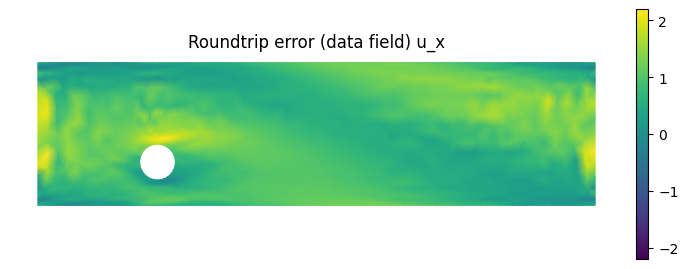

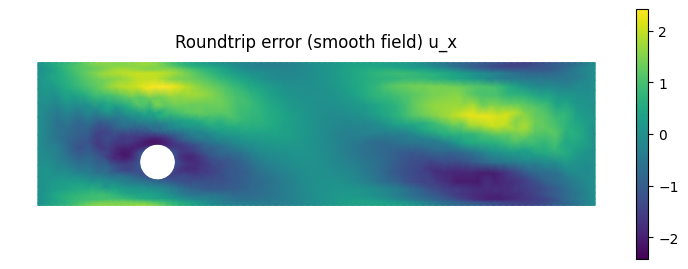

In [17]:
# ----------------------------
# Diagnostic: SpectralConv2d identity check (fft2d -> ifft2d)
# ----------------------------
SpectralConv2d = geo_FNO_def.SpectralConv2d

# Pick sample for diagnostics
DIAG_H5 = TRAIN_H5
DIAG_SAMPLE_ID = train_ds.keys[0] if 'train_ds' in globals() else 'sample_000000'

with h5py.File(DIAG_H5, 'r') as f:
    g = f[DIAG_SAMPLE_ID]
    pos_diag = g['pos'][:].astype(np.float32)      # (N,2)
    cells_diag = g['cells'][:]
    vel_diag = g['vel'][:].astype(np.float32)      # (T,N,2)

# Use real velocity snapshot for one check
u_np = vel_diag[T_OUT]                              # (N,2)

# Also test a smooth analytic field on the same points
x = pos_diag[:, 0]
y = pos_diag[:, 1]
L1 = float(x.max() - x.min())
L2 = float(y.max() - y.min())
xn = (x - x.min()) / max(L1, 1e-12)
yn = (y - y.min()) / max(L2, 1e-12)

u_smooth = np.stack([
    np.sin(2 * np.pi * xn) * np.cos(2 * np.pi * yn),
    np.cos(2 * np.pi * xn) * np.sin(2 * np.pi * yn),
], axis=-1).astype(np.float32)                      # (N,2)

w_diag_np = compute_node_quadrature_weights(pos_diag, cells_diag)

# Build spectral layer only for diagnostics (no learned weights needed)
device = torch.device(DEVICE)
layer = SpectralConv2d(
    in_channels=2,
    out_channels=2,
    modes1=MODES,
    modes2=MODES,
    s1=S1,
    s2=S2,
    L=[L1, L2],
).to(device)

# Force identity in spectral coefficients: set weights to 1 on kept modes
with torch.no_grad():
    layer.weights1.data.fill_(1.0 + 0.0j)
    layer.weights2.data.fill_(1.0 + 0.0j)

pos_t = torch.from_numpy(pos_diag).unsqueeze(0).to(device)       # (1,N,2)
w_diag = torch.from_numpy(w_diag_np).unsqueeze(0).to(device)        # (1,N)


def roundtrip(u_node_np: np.ndarray):
    # (N,2) -> (1,2,N)
    u = torch.from_numpy(u_node_np).unsqueeze(0).to(device).permute(0, 2, 1)
    with torch.no_grad():
        # fft2d returns full nonuniform spectrum with shape (m1, m2).
        # ifft2d expects the forward-pass half-spectrum layout: (2*modes1, modes2).
        u_ft_full = layer.fft2d(u, pos_t, iphi=None, code=None, w_in=w_diag)
        u_ft_half = torch.cat([
            u_ft_full[:, :, :layer.modes1, :layer.modes2],
            u_ft_full[:, :, -layer.modes1:, :layer.modes2],
        ], dim=-2)
        u_rec = layer.ifft2d(u_ft_half, pos_t, iphi=None, code=None)
    # back to (N,2)
    u_rec_np = u_rec[0].permute(1, 0).cpu().numpy().astype(np.float32)
    return u_node_np, u_rec_np


# Check both fields
orig_data, rec_data = roundtrip(u_np)
orig_smooth, rec_smooth = roundtrip(u_smooth)


def summarize(name, a, b):
    diff = b - a
    mse = float(np.mean(diff ** 2))
    rel_l2 = float(np.linalg.norm(diff) / (np.linalg.norm(a) + 1e-12))
    max_abs = float(np.max(np.abs(diff)))
    print(f'{name}: MSE={mse:.6e}  relL2={rel_l2:.6e}  max|err|={max_abs:.6e}')
    return diff


diff_data = summarize('roundtrip(data field)', orig_data, rec_data)
diff_smooth = summarize('roundtrip(smooth field)', orig_smooth, rec_smooth)

# Plot per-node error for u_x component to spot stripe artifacts
triang_diag = tri.Triangulation(pos_diag[:, 0], pos_diag[:, 1], cells_diag)

for title, diff in [
    ('Roundtrip error (data field) u_x', diff_data[:, 0]),
    ('Roundtrip error (smooth field) u_x', diff_smooth[:, 0]),
]:
    vabs = float(np.max(np.abs(diff))) + 1e-12
    plt.figure(figsize=(7, 2.8))
    im = plt.tripcolor(triang_diag, diff, shading='gouraud', vmin=-vabs, vmax=vabs)
    plt.gca().set_aspect('equal')
    plt.title(title)
    plt.axis('off')
    plt.colorbar(im, fraction=0.03, pad=0.02)
    plt.tight_layout()
    plt.show()


[Diag] conv4 manual vs direct max|diff|: 1.256323e+03
[Cause 1] conv4 complex output imag/real norm ratio: 7.130160e-01
[Cause 1] per-channel imag/real ratio: min=1.586e-01, median=9.165e-01, max=1.345e+00
[Cause 2] MSE baseline full forward              : 1.958242e-03
[Cause 2] MSE using reproduced learned conv4     : 7.466173e+03
[Cause 2] MSE replacing conv4 weights with I     : 6.605673e+04


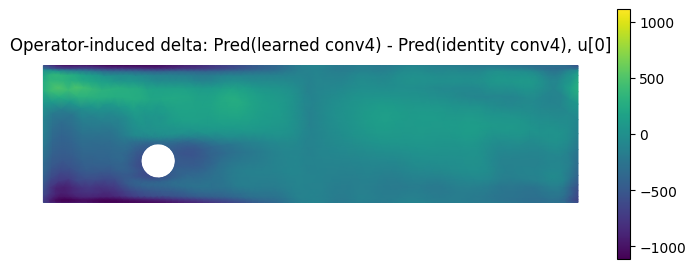

In [18]:
# ----------------------------
# Diagnostic: Cause (1) and (2)
# (1) Imaginary residual in conv4 inverse reconstruction
# (2) Learned operator effect: T^{-1}(W*T(.)) vs identity spectral W
# ----------------------------
import torch.nn.functional as F

assert 'model_eval' in globals(), 'Run the training + single-sample eval cells first.'
assert 'pos_t' in globals() and 'u_in_t' in globals(), 'Missing pos_t/u_in_t from prior cell.'
assert 'w_t' in globals(), 'Missing quadrature weights tensor w_t from prior cell.'

model_eval.eval()

# Ground truth tensor if available
if 'u_out_np' in globals():
    u_out_t = torch.from_numpy(u_out_np).unsqueeze(0).to(pos_t.device)
else:
    with h5py.File(H5_PATH, 'r') as f:
        u_out_t = torch.from_numpy(f[sample_id]['vel'][T_OUT].astype(np.float32)).unsqueeze(0).to(pos_t.device)


def conv4_preoutput_features(model, u_in_node, x_node):
    """Reproduce model forward up to the input of conv4 (tensor `uc`)."""
    grid = model.get_grid([u_in_node.shape[0], model.s1, model.s2], u_in_node.device).permute(0, 3, 1, 2)

    u = model.fc0(u_in_node).permute(0, 2, 1)  # (b,width,N)

    uc = model.conv0(u, x_in=x_node, iphi=None, code=None) + model.b0(grid)
    uc = F.gelu(uc)

    uc = model.conv1(uc) + model.w1(uc) + model.b1(grid)
    uc = F.gelu(uc)

    uc = model.conv2(uc) + model.w2(uc) + model.b2(grid)
    uc = F.gelu(uc)

    uc = model.conv3(uc) + model.w3(uc) + model.b3(grid)
    uc = F.gelu(uc)

    return uc


def conv4_ifft_complex(conv4, out_half, x_out):
    """Compute complex Y before .real in ifft2d path."""
    batchsize = x_out.shape[0]
    N = x_out.shape[1]
    device = x_out.device
    m1 = 2 * conv4.modes1
    m2 = 2 * conv4.modes2 - 1

    k_x1 = torch.cat((
        torch.arange(0, conv4.modes1, device=device),
        torch.arange(-conv4.modes1, 0, device=device)
    ), 0).reshape(m1, 1).repeat(1, m2)

    k_x2 = torch.cat((
        torch.arange(0, conv4.modes2, device=device),
        torch.arange(-(conv4.modes2 - 1), 0, device=device)
    ), 0).reshape(1, m2).repeat(m1, 1)

    x = x_out
    K1 = torch.outer(x[:, :, 0].reshape(-1), k_x1.reshape(-1)).reshape(batchsize, N, m1, m2)
    K2 = torch.outer(x[:, :, 1].reshape(-1), k_x2.reshape(-1)).reshape(batchsize, N, m1, m2)
    K = K1 / conv4.L1 + K2 / conv4.L2
    basis = torch.exp(1j * 2 * np.pi * K)

    out_half_conj = out_half[..., 1:].flip(-1, -2).conj()
    out_full = torch.cat([out_half, out_half_conj], dim=-1)

    Y = torch.einsum('bcxy,bnxy->bcn', out_full, basis)  # complex
    return Y


def conv4_apply_with_weights(conv4, uc, x_out, w1, w2):
    """Apply conv4 spectral map with externally supplied complex weights."""
    uc_ft = torch.fft.rfft2(uc)

    f1 = conv4.compl_mul2d(uc_ft[:, :, :conv4.modes1, :conv4.modes2], w1)
    f2 = conv4.compl_mul2d(uc_ft[:, :, -conv4.modes1:, :conv4.modes2], w2)
    out_half = torch.cat([f1, f2], dim=-2)

    Y_complex = conv4_ifft_complex(conv4, out_half, x_out)
    Y_real = Y_complex.real
    return Y_real, Y_complex


with torch.no_grad():
    # Baseline model prediction
    pred_base = model_eval(u_in_t, x_in=pos_t, x_out=pos_t, iphi=None, x_in_w=w_t, x_out_w=w_t)

    # Features feeding conv4
    uc = conv4_preoutput_features(model_eval, u_in_t, pos_t)

    # Learned conv4
    conv4 = model_eval.conv4
    w1_eff, w2_eff = conv4._effective_weights()
    u_conv4_learn_real, u_conv4_learn_cplx = conv4_apply_with_weights(
        conv4, uc, pos_t, w1_eff, w2_eff
    )

    # Consistency check: manual conv4 path should match model conv4.
    u_conv4_direct = model_eval.conv4(uc, x_out=pos_t, iphi=None, code=None, w_out=w_t)
    forward_consistency = torch.max(torch.abs(u_conv4_direct - u_conv4_learn_real)).item()
    print(f'[Diag] conv4 manual vs direct max|diff|: {forward_consistency:.6e}')

    # Cause (1): imaginary residual diagnostics
    imag_norm = torch.norm(u_conv4_learn_cplx.imag)
    real_norm = torch.norm(u_conv4_learn_cplx.real)
    imag_ratio = (imag_norm / (real_norm + 1e-12)).item()

    imag_per_chan = torch.norm(u_conv4_learn_cplx.imag, dim=(0, 2))
    real_per_chan = torch.norm(u_conv4_learn_cplx.real, dim=(0, 2)) + 1e-12
    imag_ratio_per_chan = (imag_per_chan / real_per_chan).cpu().numpy()

    print(f'[Cause 1] conv4 complex output imag/real norm ratio: {imag_ratio:.6e}')
    print(f'[Cause 1] per-channel imag/real ratio: min={imag_ratio_per_chan.min():.3e}, '
          f'median={np.median(imag_ratio_per_chan):.3e}, max={imag_ratio_per_chan.max():.3e}')

    # Cause (2): compare learned spectral operator vs identity spectral operator
    c = conv4.in_channels
    W1_id = torch.zeros_like(conv4.weights1)
    W2_id = torch.zeros_like(conv4.weights2)
    diag_idx = torch.arange(c, device=W1_id.device)
    W1_id[diag_idx, diag_idx, :, :] = 1.0 + 0.0j
    W2_id[diag_idx, diag_idx, :, :] = 1.0 + 0.0j

    u_conv4_id_real, _ = conv4_apply_with_weights(conv4, uc, pos_t, W1_id, W2_id)

    # Pass both through the same post-conv4 head (b4 + fc1 + fc2)
    u3 = model_eval.b4(pos_t.permute(0, 2, 1))

    def head_from_conv4_out(u_conv4_out):
        h = u_conv4_out + u3
        h = h.permute(0, 2, 1)
        h = model_eval.fc1(h)
        h = F.gelu(h)
        h = model_eval.fc2(h)
        return h

    pred_from_learned_conv4 = head_from_conv4_out(u_conv4_learn_real)
    pred_from_identity_conv4 = head_from_conv4_out(u_conv4_id_real)

    mse_base = torch.mean((pred_base - u_out_t) ** 2).item()
    mse_learned = torch.mean((pred_from_learned_conv4 - u_out_t) ** 2).item()
    mse_identity = torch.mean((pred_from_identity_conv4 - u_out_t) ** 2).item()

    print(f'[Cause 2] MSE baseline full forward              : {mse_base:.6e}')
    print(f'[Cause 2] MSE using reproduced learned conv4     : {mse_learned:.6e}')
    print(f'[Cause 2] MSE replacing conv4 weights with I     : {mse_identity:.6e}')

# Visualize difference induced by learned spectral operator
pred_learn_np = pred_from_learned_conv4[0].cpu().numpy().astype(np.float32)
pred_id_np = pred_from_identity_conv4[0].cpu().numpy().astype(np.float32)
operator_delta = pred_learn_np - pred_id_np

if 'cells' in globals() and 'pos' in globals():
    triang_diag2 = tri.Triangulation(pos[:, 0], pos[:, 1], cells)
else:
    triang_diag2 = tri.Triangulation(pos_t[0, :, 0].cpu().numpy(), pos_t[0, :, 1].cpu().numpy())

comp = 0
field = operator_delta[:, comp]
vabs = float(np.max(np.abs(field))) + 1e-12

plt.figure(figsize=(7, 2.8))
im = plt.tripcolor(triang_diag2, field, shading='gouraud', vmin=-vabs, vmax=vabs)
plt.gca().set_aspect('equal')
plt.title(f'Operator-induced delta: Pred(learned conv4) - Pred(identity conv4), u[{comp}]')
plt.axis('off')
plt.colorbar(im, fraction=0.03, pad=0.02)
plt.tight_layout()
plt.show()
